
#### Step 3: Advanced Time-Domain Feature Architecture
 
**Action:** Constructed a comprehensive feature matrix in Pandas, translating statistical EDA findings into machine-readable inputs for tree-based modeling.

> **Insights:**
> * **Point-in-Time Memory (PACF Lags):** Rather than blindly building arbitrary lags, features were strictly limited to the statistically significant spikes identified in the PACF plot (`Lag 1`, `Lag 5`, `Lag 52`). This provides XGBoost with exact historical anchors (immediate momentum, monthly mean-reversion, and annual cyclicality) while actively preventing dataframe bloat and multicollinearity.
> * **Momentum (Rolling Statistics):** Engineered 4-week rolling means and standard deviations to capture the localized, current state of the store. *Crucially, all rolling features are shifted by $t-1$ to definitively prevent target leakage.* The rolling standard deviation allows the model to sense when a department is entering a period of high volatility (heteroscedasticity) and adjust its reliance on baseline momentum accordingly.
> * **Cyclical Encoding (Fourier Terms):** Tree-based models process numerical features linearly (assuming Week 52 is extremely far away from Week 1). By engineering Sine and Cosine Fourier terms, the calendar is mathematically mapped onto a circle, allowing the algorithm to seamlessly bridge the transition from late December to early January without losing seasonal continuity.
> * **Exogenous Encoding:** Macro-economic indicators (CPI and Unemployment) are retained to provide the algorithm with context for the slow, 3% corporate baseline recovery trend identified during the initial Time Series Decomposition (Notebooks 04-06).

* **Bivariate & Exogenous Interaction Insights**

* The Markdowns and Seasonality: The dual-axis plot reveals that markdown intensity is strictly tied to the seasonal calendar, moving in near-perfect lockstep with Q4 holidays (Weeks 45-52) and early Q1 events (Week 6). This confirms that markdowns are heavily confounded with seasonality. This justifies our earlier strategy to engineer strong calendar features (like is_black_friday_week and Fourier terms), ensuring thhe e model attributes tbaseline sales lift to the calendar event first, isolating the true price elasticity of the markdowns.

* Fuel Price Inelasticity (CCF): A Cross-Correlation Function (CCF) analyzing fuel prices against network sales up to a 12-week lag showed no statistically significant relationship (all lags remained within the confidence interval). Consequently, we can definitively exclude engineered lag features for fuel prices to prevent dataframe bloat and reduce noise, retaining only the raw current-week value as a macro context metric.
***

In [2]:
import config
import pandas as pd
import numpy as np

# 1. Setup
df = pd.read_parquet(config.GOLD_MASTER_PATH)
df['date'] = pd.to_datetime(df['date'])

# ==========================================
# PHASE 1: SCAFFOLD & LOG 
# ==========================================
# Build the continuous calendar using the modern 'cross' join
calendar_df = pd.DataFrame({'date': pd.date_range(df['date'].min(), df['date'].max(), freq='W-FRI')})
unique_entities = df[['store', 'dept']].drop_duplicates()
scaffold = unique_entities.merge(calendar_df, how='cross')

# Flag the real rows before merging
df['is_real_sales_data'] = True

# Merge and Impute
df_continuous = scaffold.merge(df, on=['store', 'dept', 'date'], how='left')
df_continuous['weekly_sales'] = df_continuous['weekly_sales'].fillna(0.0)
df_continuous['is_real_sales_data'] = df_continuous['is_real_sales_data'].fillna(False)

# Apply Log Stabilization
df_continuous['sales_log'] = np.log1p(df_continuous['weekly_sales'])


# ==========================================
# PHASE 2: CALENDAR FEATURES
# ==========================================
# CRITICAL: Always sort before doing any time-series math
df_continuous = df_continuous.sort_values(['store', 'dept', 'date']).reset_index(drop=True)

# Extract week number once to keep the math clean
week_num = df_continuous['date'].dt.isocalendar().week.astype('float64')

# Standard line-by-line assignments (Very easy to read and debug)
df_continuous['month'] = df_continuous['date'].dt.month
df_continuous['week_of_year'] = week_num
df_continuous['sin_week'] = np.sin(2 * np.pi * week_num / 52)
df_continuous['cos_week'] = np.cos(2 * np.pi * week_num / 52)


# ==========================================
# PHASE 3: LAGS & MOMENTUM
# ==========================================
# Create a single grouping object so Pandas doesn't have to re-sort every time
grouped = df_continuous.groupby(['store', 'dept'])['sales_log']

# Direct Lags
df_continuous['lag_1'] = grouped.shift(1)
df_continuous['lag_5'] = grouped.shift(5)
df_continuous['lag_52'] = grouped.shift(52)

# Rolling Stats (Using lambda to safely shift BEFORE rolling)
df_continuous['rolling_4wk_mean'] = grouped.transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
df_continuous['rolling_4wk_std'] = grouped.transform(lambda x: x.shift(1).rolling(4).std())
df_continuous['rolling_12wk_max'] = grouped.transform(lambda x: x.shift(1).rolling(12, min_periods=1).max())


# ==========================================
# PHASE 4: CLEANUP
# ==========================================
# Drop the first year (because lag_52 is empty)
df_model_ready = df_continuous.dropna(subset=['lag_52']).copy()

# Drop the fake scaffold rows (so we don't train on 0's)
df_model_ready = df_model_ready[df_model_ready['is_real_sales_data'] == True]

# Drop the tracking column
df_model_ready = df_model_ready.drop(columns=['is_real_sales_data'])

print(f"Pipeline Complete. Final Shape: {df_model_ready.shape}")

/tmp/ipykernel_2149/2731225061.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_continuous['is_real_sales_data'] = df_continuous['is_real_sales_data'].fillna(False)


Pipeline Complete. Final Shape: (269196, 31)


In [3]:
df = pd.read_parquet(config.GOLD_MASTER_PATH)
df.shape

(421570, 22)

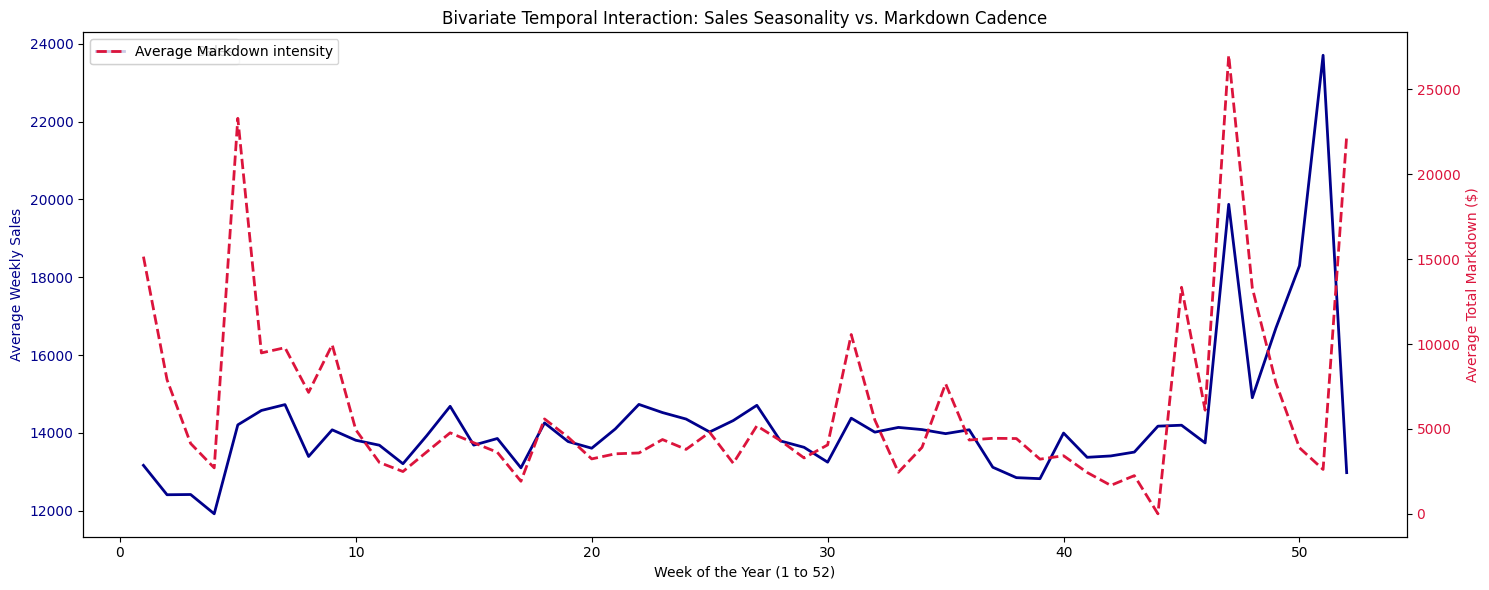

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Sum markdowns into a single column (if you haven't already)
markdown_cols = ['markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5']
df_continuous['total_markdown'] = df_continuous[markdown_cols].fillna(0).sum(axis=1)

# 2. Aggregate data by the 52 weeks of the year
weekly_seasonality = df_continuous.groupby('week_of_year').agg({
    'weekly_sales': 'mean',
    'total_markdown': 'mean'
}).reset_index()

# 3. Create the Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(15, 6))

# Axis 1: Weekly Sales (Blue)
sns.lineplot(data=weekly_seasonality, x='week_of_year', y='weekly_sales', 
             ax=ax1, color='darkblue', linewidth=2, label='Average Sales')
ax1.set_xlabel('Week of the Year (1 to 52)')
ax1.set_ylabel('Average Weekly Sales', color='darkblue')
ax1.tick_params(axis='y', labelcolor='darkblue')

# Axis 2: Total Markdowns (Red)
ax2 = ax1.twinx()  # This creates the second Y-axis sharing the same X-axis
sns.lineplot(data=weekly_seasonality, x='week_of_year', y='total_markdown', 
             ax=ax2, color='crimson', linewidth=2, linestyle='--', label='Average Markdown intensity')
ax2.set_ylabel('Average Total Markdown ($)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Bivariate Temporal Interaction: Sales Seasonality vs. Markdown Cadence')
fig.tight_layout()
plt.show()

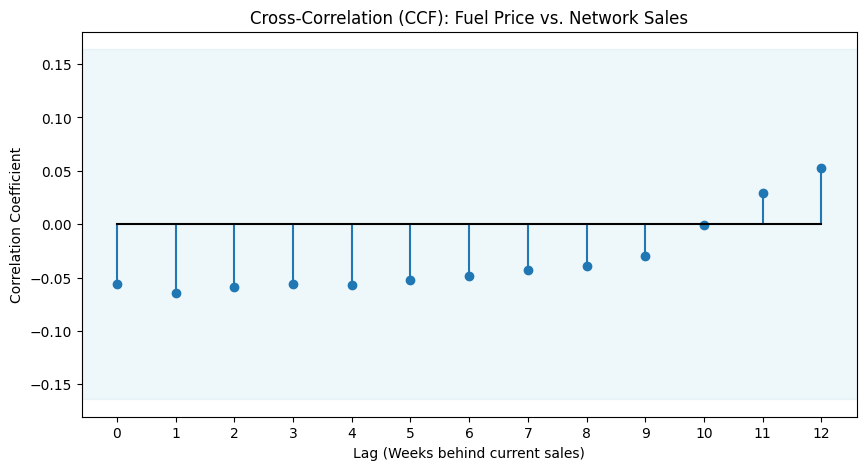

In [5]:

import statsmodels.api as sm

# 1. Aggregate to the macro network level over time
# We need the chronological timeline, not the 52-week calendar
macro_ts = df_continuous.groupby('date').agg({
    'weekly_sales': 'sum',
    'fuel_price': 'mean'
}).sort_index()

# 2. Calculate Cross-Correlation
# We test looking back up to 12 weeks
lags_to_test = 12
ccf_values = sm.tsa.stattools.ccf(
    macro_ts['fuel_price'], 
    macro_ts['weekly_sales'], 
    adjusted=False
)[:lags_to_test + 1]

# 3. Create the Lollipop Plot
plt.figure(figsize=(10, 5))
plt.stem(range(lags_to_test + 1), ccf_values, basefmt="black")

# Add a confidence interval band (approximate for visual reference)
conf_interval = 1.96 / (len(macro_ts) ** 0.5)
plt.axhspan(-conf_interval, conf_interval, alpha=0.2, color='lightblue')

plt.title('Cross-Correlation (CCF): Fuel Price vs. Network Sales')
plt.xlabel('Lag (Weeks behind current sales)')
plt.ylabel('Correlation Coefficient')
plt.xticks(range(lags_to_test + 1))
plt.show()